# FEATURE SELECTION - VN INDEX

## Import libraries

In [437]:
import os
import sys
import random
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname
from sklearn.inspection import permutation_importance
import xgboost as xgb
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import *
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

In [438]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Helper functions

In [439]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [440]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"
FEATURE_COLUMNS = []  # all TA indicators

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [441]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Load data

In [442]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [443]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [444]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [445]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [446]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "adjust": float,
    "change": float,
    "percent_change": float,
    "matching_volume": float,
    "matching_value": float,
    "negotiate_volume": float,
    "negotiate_value": float,
    "number_of_buy_orders": float,
    "buy_volume": float,
    "average_volume_per_buy_order": float,
    "number_of_sell_orders": float,
    "sell_volume": float,
    "average_volume_per_sell_order": float,
    "net_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [447]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970000,4.740000,8.169220e+06,5.152538e+11,350040.0,2.910304e+10,26816.0,5.268141e+07,1965.000000,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.190,25.363333,4.106667,1.314382e+07,8.298321e+11,769057.0,4.594466e+10,27442.0,5.068024e+07,1852.333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.240,21.756667,3.473333,1.811842e+07,1.144410e+12,1188073.0,6.278627e+10,28068.0,4.867907e+07,1739.666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150000,2.840000,2.309302e+07,1.458989e+12,1607090.0,7.962789e+10,28694.0,4.667790e+07,1627.000000,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580000,-2.970000,1.384280e+07,8.374665e+11,226000.0,1.209960e+10,14464.0,1.933131e+07,1337.000000,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.445000,1.837000,7.158068e+08,2.227241e+13,23581058.0,7.924402e+11,476711.0,1.233848e+09,2591.300000,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050000,1.980000,7.313611e+08,2.264621e+13,23192200.0,7.774309e+11,486603.0,1.253004e+09,2575.000000,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480000,0.400000,9.667547e+08,3.120594e+13,22413147.0,7.795734e+11,598087.0,1.575227e+09,2634.000000,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710000,-0.360000,1.083635e+09,3.567852e+13,62225450.0,1.856894e+12,694266.0,1.862364e+09,2682.000000,597096.0,1.892734e+09,3170.0,-3.036983e+07


## Data transformation

In [448]:
vn_index_df.shape

(6566, 19)

### Remove DAYOFFS

In [449]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

### Calculate return

In [450]:
# vn_index_df_t2 = vn_index_df_t1.copy()
# vn_index_df_t2[f"return_{FORECAST_HORIZON}"] = (
#     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) - vn_index_df_t1["close"]
# )
# # vn_index_df_t2[f"log_return_{FORECAST_HORIZON}"] = np.log(
# #     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) / vn_index_df_t2["close"]
# # )
# vn_index_df_t2 = vn_index_df_t2.dropna(how="any").reset_index(drop=True)
# vn_index_df_t2.shape

In [451]:
vn_index_df_t_final = vn_index_df_t1
vn_index_df_t_final.shape

(4690, 19)

## Create features

In [452]:
# vn_index_df_cf1 = add_one_for_all_ta(vn_index_df_t_final)
vn_index_df_cf1 = add_bbands(vn_index_df_t_final, n=list(range(2, 21)))
vn_index_df_cf1.shape

(4690, 456)

In [453]:
vn_index_df_cf_final = vn_index_df_cf1
vn_index_df_cf_final.shape

(4690, 456)

## Filter columns

In [454]:
FEATURE_COLUMNS = list(
    vn_index_df_cf_final.columns.drop(
        [
            DATE_COLUMN,
            TARGET_COLUMN,
        ]
    )
)
len(FEATURE_COLUMNS)

454

## Feature Importance

In [455]:
input_df = vn_index_df_cf_final
input_df.shape

(4690, 456)

In [456]:
TOP_N = 50

In [457]:
len(FEATURE_COLUMNS)

454

In [458]:
TARGET_COLUMN

'close'

### Prepare data

In [459]:
input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])
input_df = input_df.sort_values(by=[DATE_COLUMN]).reset_index(drop=True)

X = input_df[FEATURE_COLUMNS]
y = input_df[TARGET_COLUMN]

In [460]:
input_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_bb_20_bandwidth_slope,close_bb_20_bandwidth_acceleration,close_bb_20_pct_b,close_bb_20_pct_b_slope,close_bb_20_pct_b_gt_1,close_bb_20_pct_b_lt_0,close_bb_20_above_upper,close_bb_20_below_lower,close_bb_20_inside_bands,close_bb_20_position
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8.169220e+06,5.152538e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,True,0
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,2.309302e+07,1.458989e+12,...,NaN,NaN,NaN,NaN,False,False,False,False,True,0
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,1.384280e+07,8.374665e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,True,0
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,1.216691e+07,7.659728e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,True,0
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8.930090e+06,5.844466e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4685,2026-02-20,1829.151,1851.448,1821.603,1849.325,1849.325,28.235,1.551,6.846983e+08,2.152480e+13,...,-0.003677,0.002547,0.818102,0.053949,False,False,False,False,True,0
4686,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050,1.980,7.313611e+08,2.264621e+13,...,0.002366,0.006043,0.887543,0.069440,False,False,False,False,True,0
4687,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480,0.400,9.667547e+08,3.120594e+13,...,0.004535,0.002169,0.905573,0.018031,False,False,False,False,True,0
4688,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710,-0.360,1.083635e+09,3.567852e+13,...,0.003006,-0.001528,0.819302,-0.086272,False,False,False,False,True,0


# TEST

In [461]:
# CELL 1
DATE_COLUMN = "date"
TARGET_COLUMN = "close"
HORIZON = 5  # predict close N days ahead (change to 5, 10, etc.)
RANDOM_SEED = 42

FEATURE_COLUMNS = [c for c in input_df.columns if c not in [DATE_COLUMN, TARGET_COLUMN]]

print(f"Features: {len(FEATURE_COLUMNS)}")
print(f"Rows:     {len(input_df)}")

Features: 454
Rows:     4690


In [462]:
# CELL 2
import numpy as np

df = input_df.copy()

# --- Create FORWARD target: absolute close price N days ahead ---
df["fwd_close"] = df[TARGET_COLUMN].shift(-HORIZON)  # ← was pct-change fwd_return

# --- Volumes → pct_change ---
vol_cols = [
    "matching_volume",
    "matching_value",
    "negotiate_volume",
    "negotiate_value",
    "buy_volume",
    "sell_volume",
    "number_of_buy_orders",
    "number_of_sell_orders",
    "average_volume_per_buy_order",
    "average_volume_per_sell_order",
    "net_volume",
]
for col in vol_cols:
    if col in df.columns:
        df[f"{col}_chg"] = df[col].pct_change().replace([np.inf, -np.inf], np.nan)
        df.drop(columns=[col], inplace=True)

# --- Drop date ---
if DATE_COLUMN in df.columns:
    df.drop(columns=[DATE_COLUMN], inplace=True)

# ← REMOVED: rolling_vol normalization block (not needed for price target)

# Drop NaNs: last HORIZON rows have no forward target
df.dropna(subset=["fwd_close"], inplace=True)

# --- Fill remaining NaNs in features ---
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# --- Define features ---
FEATURE_COLUMNS = [c for c in df.columns if c != "fwd_close"]  # ← simplified

print(f"Shape after transforms: {df.shape}")
print(f"Feature count:          {len(FEATURE_COLUMNS)}")
print(f"Predicting {HORIZON}-day ahead CLOSE PRICE")

Shape after transforms: (4685, 456)
Feature count:          455
Predicting 5-day ahead CLOSE PRICE


In [463]:
# CELL 3
GAP = HORIZON
train_size = int(len(df) * 0.8)

df_train = df.iloc[:train_size]
df_val = df.iloc[train_size + GAP :]

X_train = df_train[FEATURE_COLUMNS]
y_train = df_train["fwd_close"]  # ← was target_normalized
X_val = df_val[FEATURE_COLUMNS]
y_val = df_val["fwd_close"]  # ← was target_normalized

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")

X_train: (3748, 455)
X_val:   (932, 455)


In [464]:
# CELL 4
from sklearn.metrics import mean_squared_error


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


naive_mean = rmse(y_val, np.full(len(y_val), y_train.mean()))
naive_zero = rmse(y_val, np.zeros(len(y_val)))

print(f"Naive mean RMSE: {naive_mean:.4f}  ← must beat this")
print(f"Naive zero RMSE: {naive_zero:.4f}")

Naive mean RMSE: 615.0484  ← must beat this
Naive zero RMSE: 1297.4765


In [465]:
# CELL 5
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np

# Ensure we are only looking at numeric data for these statistical tests
X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])

# --- Correlation with target ---
# Using X_train_num ensures we don't hit "TypeError: could not convert string to float"
corr = X_train_num.corrwith(y_train).abs().sort_values(ascending=False)

print("=== TOP 20 FEATURE CORRELATIONS ===")
print(corr.head(20))
print(f"\nMean |corr|:           {corr.mean():.4f}")
print(f"Features |corr|>0.05: {(corr > 0.05).sum()}")
print(f"Features |corr|>0.10: {(corr > 0.10).sum()}")
print(f"Features |corr|>0.20: {(corr > 0.20).sum()}")

# --- Distribution shift (KS Test) ---
# We drop NaNs per column for the KS test to avoid getting 'nan' results
drift = []
for col in X_train_num.columns:
    sample1 = X_train_num[col].dropna()
    sample2 = X_val_num[col].dropna() if col in X_val_num.columns else None

    if sample2 is not None and len(sample1) > 0 and len(sample2) > 0:
        stat, p = ks_2samp(sample1, sample2)
        drift.append((col, stat, p))

drift_df = pd.DataFrame(drift, columns=["feature", "ks_stat", "p_value"])
drift_df = drift_df.sort_values("ks_stat", ascending=False)

print("\n=== TOP 10 DRIFTED FEATURES ===")
print(drift_df.head(10))
print(f"\nFeatures KS>0.2: {(drift_df['ks_stat'] > 0.2).sum()}")
print(f"Features KS>0.1: {(drift_df['ks_stat'] > 0.1).sum()}")

# --- Flag zero-variance features ---
# Standard deviation check on numeric columns
zero_var = X_train_num.columns[X_train_num.std() < 1e-6].tolist()
if zero_var:
    print(f"\n⚠ Zero-variance features (drop these): {zero_var}")
else:
    print("\n✓ No zero-variance features")

# --- Flag highly correlated feature pairs ---
corr_matrix = X_train_num.corr().abs()
# Create a mask for the upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if not np.isnan(upper.loc[row, col]) and upper.loc[row, col] > 0.95
]

redundant_df = pd.DataFrame(redundant, columns=["feature_a", "feature_b", "corr"])
redundant_df = redundant_df.sort_values("corr", ascending=False)

print(f"\n=== REDUNDANT FEATURE PAIRS (corr > 0.95): {len(redundant_df)} pairs ===")
print(redundant_df.head(20))

# --- Drop redundant features from X_train / X_val ---
# For each highly-correlated pair, drop the one with LOWER target correlation
# --- Drop redundant features from X_train / X_val ---
to_drop = set()
for _, row in redundant_df.iterrows():
    a, b = row["feature_a"], row["feature_b"]
    if corr.get(a, 0) >= corr.get(b, 0):
        to_drop.add(b)
    else:
        to_drop.add(a)

to_drop.update(zero_var)
to_drop = [c for c in to_drop if c in X_train.columns]

X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)

# --- Drop leaky features ---
leaky = corr[corr > 0.9].index.tolist()
leaky = [c for c in leaky if c in X_train.columns]

X_train = X_train.drop(columns=leaky)
X_val   = X_val.drop(columns=leaky)

FEATURE_COLUMNS = X_train.columns.tolist()

print(f"Dropped {len(to_drop)} redundant/zero-var features: {sorted(to_drop)}")
print(f"Dropped {len(leaky)} leaky features (|corr|>0.9): {sorted(leaky)}")
print(f"Remaining features: {len(FEATURE_COLUMNS)}")

# --- Recompute full correlation analysis on cleaned features ---
X_train_clean = X_train.select_dtypes(include=[np.number])
X_val_clean   = X_val.select_dtypes(include=[np.number])

corr = X_train_clean.corrwith(y_train).abs().sort_values(ascending=False)

print("\n=== TOP 20 FEATURE CORRELATIONS (after cleaning) ===")
print(corr.head(20))
print(f"\nMean |corr|:           {corr.mean():.4f}")
print(f"Features |corr|>0.05: {(corr > 0.05).sum()}")
print(f"Features |corr|>0.10: {(corr > 0.10).sum()}")
print(f"Features |corr|>0.20: {(corr > 0.20).sum()}")

# --- Recompute distribution shift ---
drift = []
for col in X_train_clean.columns:
    sample1 = X_train_clean[col].dropna()
    sample2 = X_val_clean[col].dropna() if col in X_val_clean.columns else None
    if sample2 is not None and len(sample1) > 0 and len(sample2) > 0:
        stat, p = ks_2samp(sample1, sample2)
        drift.append((col, stat, p))

drift_df = pd.DataFrame(drift, columns=["feature", "ks_stat", "p_value"])
drift_df = drift_df.sort_values("ks_stat", ascending=False)

print("\n=== TOP 10 DRIFTED FEATURES (after cleaning) ===")
print(drift_df.head(10))
print(f"\nFeatures KS>0.2: {(drift_df['ks_stat'] > 0.2).sum()}")
print(f"Features KS>0.1: {(drift_df['ks_stat'] > 0.1).sum()}")

=== TOP 20 FEATURE CORRELATIONS ===
adjust               0.997116
close                0.997116
close_bb_2_middle    0.996881
low                  0.996860
high                 0.996837
close_bb_2_lower     0.996743
close_bb_3_middle    0.996626
open                 0.996573
close_bb_2_upper     0.996533
close_bb_3_lower     0.996451
close_bb_4_middle    0.996358
close_bb_4_lower     0.996149
close_bb_5_middle    0.996088
close_bb_3_upper     0.996069
close_bb_5_lower     0.995830
close_bb_6_middle    0.995817
close_bb_4_upper     0.995605
close_bb_7_middle    0.995544
close_bb_6_lower     0.995503
close_bb_8_middle    0.995274
dtype: float64

Mean |corr|:           0.2209
Features |corr|>0.05: 199
Features |corr|>0.10: 141
Features |corr|>0.20: 81


d:\GIT\master-thesis\mt_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\GIT\master-thesis\mt_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



=== TOP 10 DRIFTED FEATURES ===
               feature   ks_stat        p_value
331  close_bb_20_upper  0.848691  5.237096e-322
313  close_bb_19_upper  0.847885  5.286502e-322
295  close_bb_18_upper  0.847612  5.335909e-322
259  close_bb_16_upper  0.847612  5.335909e-322
241  close_bb_15_upper  0.847606  5.335909e-322
277  close_bb_17_upper  0.847606  5.335909e-322
187  close_bb_12_upper  0.847601  5.335909e-322
223  close_bb_14_upper  0.846800  5.385316e-322
205  close_bb_13_upper  0.846539  5.385316e-322
169  close_bb_11_upper  0.846261  5.385316e-322

Features KS>0.2: 63
Features KS>0.1: 185

⚠ Zero-variance features (drop these): ['close_bb_2_position']

=== REDUNDANT FEATURE PAIRS (corr > 0.95): 2166 pairs ===
               feature_a           feature_b      corr
9                 adjust               close  1.000000
611   close_bb_11_middle  close_bb_10_middle  0.999969
501   close_bb_10_middle   close_bb_9_middle  0.999969
731   close_bb_12_middle  close_bb_11_middle  0.999969

In [466]:
# CELL 6
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Prepare numeric-only data for Ridge
# This prevents the "could not convert string to float" error
X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])

# 2. Fill remaining NaNs (Ridge requirement)
# We fill with 0 or median. Median is usually safer for financial data.
X_train_clean = X_train_num.fillna(X_train_num.median())
X_val_clean = X_val_num.fillna(
    X_train_num.median()
)  # Fill val with train median to avoid lookahead

# --- Model 1: Ridge (requires scaling, zero overfit risk) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_val_scaled = scaler.transform(X_val_clean)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_rmse = rmse(y_val, ridge.predict(X_val_scaled))

# --- Model 2: XGBoost top 10 features only ---
# We use X_train directly here as XGBoost handles NaNs and non-scaled data
top10 = corr.head(20).index.tolist()
xgb_top10 = xgb.XGBRegressor(
    n_estimators=5000,
    max_depth=12,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=30,
    reg_alpha=1.0,
    reg_lambda=10.0,
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    enable_categorical=True,  # Added this to handle categories if present
    random_state=RANDOM_SEED,
)
xgb_top10.fit(X_train[top10], y_train, eval_set=[(X_val[top10], y_val)], verbose=False)
xgb_top10_rmse = rmse(y_val, xgb_top10.predict(X_val[top10]))

# --- Model 3: XGBoost all features ---
xgb_full = xgb.XGBRegressor(
    n_estimators=5000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=30,
    reg_alpha=1.0,
    reg_lambda=10.0,
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    enable_categorical=True,  # Added this
    random_state=RANDOM_SEED,
)
xgb_full.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_full_rmse = rmse(y_val, xgb_full.predict(X_val))

# --- Summary ---
print("=" * 40)
print(f"Naive mean RMSE:      {naive_mean:.4f}  ← baseline")
print(
    f"Ridge RMSE:           {ridge_rmse:.4f}  {'✓ beats baseline' if ridge_rmse < naive_mean else '✗ no signal'}"
)
print(
    f"XGB top10 RMSE:       {xgb_top10_rmse:.4f}  {'✓ beats baseline' if xgb_top10_rmse < naive_mean else '✗ no signal'}"
)
print(
    f"XGB full RMSE:        {xgb_full_rmse:.4f}  {'✓ beats baseline' if xgb_full_rmse < naive_mean else '✗ no signal'}"
)
print("=" * 40)

Naive mean RMSE:      615.0484  ← baseline
Ridge RMSE:           900181.2432  ✗ no signal
XGB top10 RMSE:       348.3799  ✓ beats baseline
XGB full RMSE:        209.1454  ✓ beats baseline


In [467]:
# CELL 7
results = {
    "Ridge": ridge_rmse,
    "XGB top10": xgb_top10_rmse,
    "XGB full": xgb_full_rmse,
}
best_rmse = min(results.values())
best_model = min(results, key=results.get)

if best_rmse < naive_mean:
    improvement = (naive_mean - best_rmse) / naive_mean * 100
    print(f"✓ SIGNAL EXISTS — {best_model} beats baseline by {improvement:.1f}%")
    print(f"  → Proceed to hyperparameter tuning")
else:
    print("✗ NO SIGNAL — features cannot predict return_5 reliably")
    print("  → Options:")
    print("     1. Change target: try return_1 or direction (up/down classification)")
    print("     2. Add features: sector return, order imbalance, market index")
    print("     3. Change the stock — some stocks are simply not predictable")

✓ SIGNAL EXISTS — XGB full beats baseline by 66.0%
  → Proceed to hyperparameter tuning


# END TEST

In [143]:
input_df_train = input_df[input_df["date"].between(TRAIN_RANGE[0], TRAIN_RANGE[1])]
input_df_train

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_bb_20_bandwidth_slope,close_bb_20_bandwidth_acceleration,close_bb_20_pct_b,close_bb_20_pct_b_slope,close_bb_20_pct_b_gt_1,close_bb_20_pct_b_lt_0,close_bb_20_above_upper,close_bb_20_below_lower,close_bb_20_inside_bands,close_bb_20_position
0,2008-03-07,640.14,640.14,640.14,640.14,640.14,28.97,4.74,8169220.0,5.152538e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
1,2008-03-10,658.29,658.29,658.29,658.29,658.29,18.15,2.84,23093020.0,1.458989e+12,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
2,2008-03-11,638.71,638.71,638.71,638.71,638.71,-19.58,-2.97,13842800.0,8.374665e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
3,2008-03-12,643.90,643.90,643.90,643.90,643.90,5.19,0.81,12166910.0,7.659728e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
4,2008-03-13,647.60,647.60,647.60,647.60,647.60,3.70,0.57,8930090.0,5.844466e+11,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3601,2021-12-27,1485.10,1490.12,1469.91,1488.88,1488.88,11.85,0.80,717070918.0,2.054825e+13,...,0.000567,0.002517,0.786243,0.163955,False,False,False,False,True,0
3602,2021-12-28,1497.16,1499.77,1483.97,1494.39,1494.39,5.51,0.37,934384700.0,2.656725e+13,...,0.002061,0.001494,0.838427,0.052185,False,False,False,False,True,0
3603,2021-12-29,1498.30,1498.91,1485.82,1485.82,1485.82,-8.57,-0.57,794969800.0,2.326809e+13,...,0.000073,-0.001987,0.721043,-0.117384,False,False,False,False,True,0
3604,2021-12-30,1491.24,1493.38,1484.82,1485.97,1485.97,0.15,0.01,724365200.0,2.110016e+13,...,0.000408,0.000335,0.718608,-0.002435,False,False,False,False,True,0


In [144]:
input_df_val = input_df[
    input_df["date"].between(VALIDATION_RANGE[0], VALIDATION_RANGE[1])
]
input_df_val

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_bb_20_bandwidth_slope,close_bb_20_bandwidth_acceleration,close_bb_20_pct_b,close_bb_20_pct_b_slope,close_bb_20_pct_b_gt_1,close_bb_20_pct_b_lt_0,close_bb_20_above_upper,close_bb_20_below_lower,close_bb_20_inside_bands,close_bb_20_position
3606,2022-01-03,1503.675,1519.785,1495.2025,1518.755,1518.755,23.5525,1.5725,8.022430e+08,2.589249e+13,...,-0.007625,-0.007400,1.150713,0.302340,True,False,True,False,False,1
3607,2022-01-04,1508.150,1526.690,1498.2800,1525.580,1525.580,27.3000,1.8200,7.874792e+08,2.633966e+13,...,0.004039,0.011664,1.134530,-0.016183,True,False,True,False,False,1
3608,2022-01-05,1529.060,1535.820,1522.5000,1522.500,1522.500,-3.0800,-0.2000,9.556979e+08,3.050806e+13,...,0.002140,-0.001899,1.014788,-0.119742,True,False,True,False,False,1
3609,2022-01-06,1518.940,1536.240,1518.1800,1528.570,1528.570,6.0700,0.4000,1.089215e+09,3.307919e+13,...,0.004852,0.002712,1.005358,-0.009429,True,False,True,False,False,1
3610,2022-01-07,1534.440,1534.520,1524.9600,1528.480,1528.480,-0.0900,-0.0100,9.515254e+08,2.918099e+13,...,0.002513,-0.002339,0.941874,-0.063484,False,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4121,2023-12-25,1104.270,1118.310,1104.2700,1117.660,1117.660,14.6000,1.3200,5.512796e+08,1.204198e+13,...,-0.002786,-0.001833,0.669179,0.274147,False,False,False,False,True,0
4122,2023-12-26,1120.110,1123.110,1117.9300,1122.250,1122.250,4.5900,0.4100,5.752889e+08,1.303742e+13,...,-0.000713,0.002072,0.742577,0.073398,False,False,False,False,True,0
4123,2023-12-27,1123.280,1126.470,1121.9900,1121.990,1121.990,-0.2600,-0.0200,5.707377e+08,1.220434e+13,...,0.000208,0.000922,0.714776,-0.027800,False,False,False,False,True,0
4124,2023-12-28,1122.570,1130.580,1120.5000,1128.930,1128.930,6.9400,0.6200,6.149260e+08,1.307666e+13,...,-0.000829,-0.001037,0.833383,0.118606,False,False,False,False,True,0


In [145]:
X_train = input_df_train[FEATURE_COLUMNS]
X_train

,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,...,close_bb_20_bandwidth_slope,close_bb_20_bandwidth_acceleration,close_bb_20_pct_b,close_bb_20_pct_b_slope,close_bb_20_pct_b_gt_1,close_bb_20_pct_b_lt_0,close_bb_20_above_upper,close_bb_20_below_lower,close_bb_20_inside_bands,close_bb_20_position
0,640.14,640.14,640.14,640.14,640.14,28.97,4.74,8169220.0,5.152538e+11,350040.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
1,658.29,658.29,658.29,658.29,658.29,18.15,2.84,23093020.0,1.458989e+12,1607090.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
2,638.71,638.71,638.71,638.71,638.71,-19.58,-2.97,13842800.0,8.374665e+11,226000.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
3,643.90,643.90,643.90,643.90,643.90,5.19,0.81,12166910.0,7.659728e+11,290070.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
4,647.60,647.60,647.60,647.60,647.60,3.70,0.57,8930090.0,5.844466e+11,289160.0,...,NaN,NaN,NaN,NaN,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3601,1485.10,1490.12,1469.91,1488.88,1488.88,11.85,0.80,717070918.0,2.054825e+13,35037214.0,...,0.000567,0.002517,0.786243,0.163955,False,False,False,False,True,0
3602,1497.16,1499.77,1483.97,1494.39,1494.39,5.51,0.37,934384700.0,2.656725e+13,67850382.0,...,0.002061,0.001494,0.838427,0.052185,False,False,False,False,True,0
3603,1498.30,1498.91,1485.82,1485.82,1485.82,-8.57,-0.57,794969800.0,2.326809e+13,48910393.0,...,0.000073,-0.001987,0.721043,-0.117384,False,False,False,False,True,0
3604,1491.24,1493.38,1484.82,1485.97,1485.97,0.15,0.01,724365200.0,2.110016e+13,23495596.0,...,0.000408,0.000335,0.718608,-0.002435,False,False,False,False,True,0


In [146]:
y_train = input_df_train[TARGET_COLUMN]
y_train

0        3.660
1      -42.580
2      -50.450
3      -70.450
4      -82.780
         ...  
3601    29.875
3602    31.190
3603    36.680
3604    42.600
3605    30.200
Name: return_5, Length: 3606, dtype: float64

In [147]:
X_val = input_df_val[FEATURE_COLUMNS]
X_val

,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,...,close_bb_20_bandwidth_slope,close_bb_20_bandwidth_acceleration,close_bb_20_pct_b,close_bb_20_pct_b_slope,close_bb_20_pct_b_gt_1,close_bb_20_pct_b_lt_0,close_bb_20_above_upper,close_bb_20_below_lower,close_bb_20_inside_bands,close_bb_20_position
3606,1503.675,1519.785,1495.2025,1518.755,1518.755,23.5525,1.5725,8.022430e+08,2.589249e+13,44791786.0,...,-0.007625,-0.007400,1.150713,0.302340,True,False,True,False,False,1
3607,1508.150,1526.690,1498.2800,1525.580,1525.580,27.3000,1.8200,7.874792e+08,2.633966e+13,49990429.0,...,0.004039,0.011664,1.134530,-0.016183,True,False,True,False,False,1
3608,1529.060,1535.820,1522.5000,1522.500,1522.500,-3.0800,-0.2000,9.556979e+08,3.050806e+13,71428645.0,...,0.002140,-0.001899,1.014788,-0.119742,True,False,True,False,False,1
3609,1518.940,1536.240,1518.1800,1528.570,1528.570,6.0700,0.4000,1.089215e+09,3.307919e+13,44507970.0,...,0.004852,0.002712,1.005358,-0.009429,True,False,True,False,False,1
3610,1534.440,1534.520,1524.9600,1528.480,1528.480,-0.0900,-0.0100,9.515254e+08,2.918099e+13,75594863.0,...,0.002513,-0.002339,0.941874,-0.063484,False,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4121,1104.270,1118.310,1104.2700,1117.660,1117.660,14.6000,1.3200,5.512796e+08,1.204198e+13,105707835.0,...,-0.002786,-0.001833,0.669179,0.274147,False,False,False,False,True,0
4122,1120.110,1123.110,1117.9300,1122.250,1122.250,4.5900,0.4100,5.752889e+08,1.303742e+13,55982754.0,...,-0.000713,0.002072,0.742577,0.073398,False,False,False,False,True,0
4123,1123.280,1126.470,1121.9900,1121.990,1121.990,-0.2600,-0.0200,5.707377e+08,1.220434e+13,178938561.0,...,0.000208,0.000922,0.714776,-0.027800,False,False,False,False,True,0
4124,1122.570,1130.580,1120.5000,1128.930,1128.930,6.9400,0.6200,6.149260e+08,1.307666e+13,84624950.0,...,-0.000829,-0.001037,0.833383,0.118606,False,False,False,False,True,0


In [148]:
y_val = input_df_val[TARGET_COLUMN]
y_val

3606   -15.0450
3607   -33.2700
3608   -11.9900
3609   -32.5200
3610   -32.4600
         ...   
4121    13.6125
4122     9.4700
4123    22.1800
4124    21.7900
4125    24.7500
Name: return_5, Length: 520, dtype: float64

### Model

In [149]:
# n_estimators = 4000
# max_depth = 6  # was 16 — most critical fix, deep trees = instant overfit
# learning_rate = 0.05  # slightly higher so useful signal accumulates faster
# subsample = 0.8
# colsample_bytree = 0.8
# min_child_weight = 10  # require more samples per leaf
# reg_alpha = 0.1  # L1 — pushes weak feature weights to zero
# reg_lambda = 5.0  # L2 — penalizes large weights
# gamma = 1.0  # minimum loss reduction to make a split
# n_repeats = 60

In [150]:
model = xgb.XGBRegressor(
    n_estimators=4000,
    max_depth=4,  # shallower — 4075 rows, 98 features
    learning_rate=0.01,  # slower — more stable with overlapping targets
    subsample=0.6,  # more aggressive row sampling
    colsample_bytree=0.5,  # only half the features per tree
    min_child_weight=30,  # much higher — forces conservative splits
    reg_alpha=1.0,  # stronger L1
    reg_lambda=10.0,  # stronger L2
    gamma=2.0,  # harder to split
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    random_state=RANDOM_SEED,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

[0]	validation_0-rmse:35.48732
[100]	validation_0-rmse:36.01638
[101]	validation_0-rmse:36.00671


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,'cuda'
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,None


In [151]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# --- Test 1: Ridge regression (linear, no overfitting risk) ---
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_val)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
print(f"Ridge RMSE:      {ridge_rmse:.4f}")

# --- Test 2: XGBoost with only top 10 features ---
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
top_features = correlations.head(10).index.tolist()
print(f"\nTop 10 features: {top_features}")

model_top10 = xgb.XGBRegressor(
    n_estimators=4000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=30,
    reg_alpha=1.0,
    reg_lambda=10.0,
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=100,
    random_state=RANDOM_SEED,
)
model_top10.fit(
    X_train[top_features],
    y_train,
    eval_set=[(X_val[top_features], y_val)],
    verbose=100,
)

# --- Naive baseline ---
naive_rmse = np.sqrt(mean_squared_error(y_val, np.full(len(y_val), y_train.mean())))
print(f"\nNaive mean RMSE: {naive_rmse:.4f}")
print(f"Ridge RMSE:      {ridge_rmse:.4f}")
print(f"Beats baseline:  {ridge_rmse < naive_rmse}")

ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# -----------------------------
# BASELINE (GPU prediction)
# -----------------------------
baseline_pred = model.predict(X)
baseline_mse = np.mean((y - baseline_pred) ** 2)

# -----------------------------
# GPU PERMUTATION IMPORTANCE + PROGRESS
# -----------------------------
importances = []

for col in tqdm(X.columns, desc="Permutation Importance"):
    scores = []
    X_permuted = X.copy()  # FIX 2: copy once per feature, not per repeat

    for _ in range(n_repeats):
        X_permuted[col] = np.random.permutation(
            X[col].values
        )  # only shuffle the column

        pred = model.predict(X_permuted)
        mse = np.mean((y - pred) ** 2)
        scores.append(mse)

    importance = np.mean(scores) - baseline_mse
    importances.append(importance)

# -----------------------------
# CREATE IMPORTANCE DF
# -----------------------------
importance_df = pd.DataFrame(
    {"feature": X.columns, "importance": importances}
).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

# -----------------------------
# OUTPUT
# -----------------------------
print("\nFeature Importance:")
print(importance_df)

In [ ]:
importance_df

,feature,importance,importance_pct
89,close_bb_20_lower,1.836833e+02,3.382820e+01
13,average_volume_per_buy_order,8.980773e+01,1.653952e+01
41,close_bb_10_upper,1.656247e+01,3.050242e+00
87,close_bb_20_upper,1.574221e+01,2.899177e+00
95,close_bb_20_slope_middle,1.445013e+01,2.661221e+00
...,...,...,...
39,close_bb_5_inside_bands,2.646978e-23,4.874831e-24
40,close_bb_5_position,2.646978e-23,4.874831e-24
61,close_bb_10_below_lower,2.646978e-23,4.874831e-24
109,close_bb_20_position,2.646978e-23,4.874831e-24


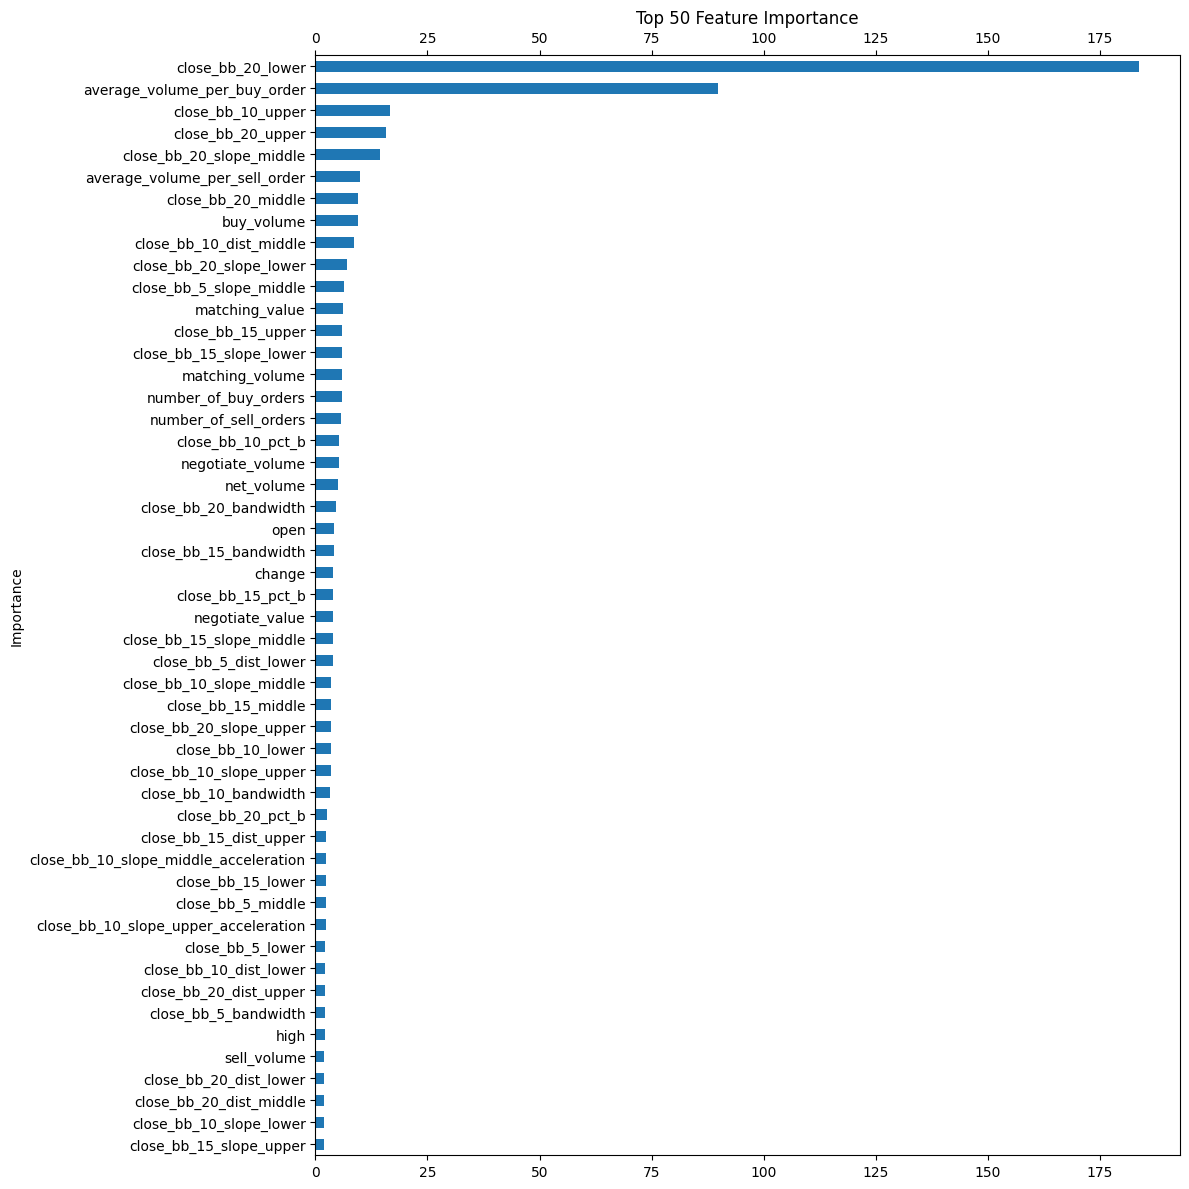

In [ ]:
top_features = (
    importance_df.sort_values("importance", ascending=False)
    .head(TOP_N)
    .set_index("feature")["importance"]
).sort_values(ascending=True)

# Plot
ax = top_features.plot(kind="barh", figsize=(12, 12))

plt.title(f"Top {TOP_N} Feature Importance")
plt.ylabel("Importance")

# Show x ticks on both top and bottom
ax.xaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", top=True, bottom=True, labeltop=True)

plt.tight_layout()
plt.show()

In [ ]:
TOP_N_FEATURES = list(top_features.index)
TOP_N_FEATURES

['close_bb_15_slope_upper',
 'close_bb_10_slope_lower',
 'close_bb_20_dist_middle',
 'close_bb_20_dist_lower',
 'sell_volume',
 'high',
 'close_bb_5_bandwidth',
 'close_bb_20_dist_upper',
 'close_bb_10_dist_lower',
 'close_bb_5_lower',
 'close_bb_10_slope_upper_acceleration',
 'close_bb_5_middle',
 'close_bb_15_lower',
 'close_bb_10_slope_middle_acceleration',
 'close_bb_15_dist_upper',
 'close_bb_20_pct_b',
 'close_bb_10_bandwidth',
 'close_bb_10_slope_upper',
 'close_bb_10_lower',
 'close_bb_20_slope_upper',
 'close_bb_15_middle',
 'close_bb_10_slope_middle',
 'close_bb_5_dist_lower',
 'close_bb_15_slope_middle',
 'negotiate_value',
 'close_bb_15_pct_b',
 'change',
 'close_bb_15_bandwidth',
 'open',
 'close_bb_20_bandwidth',
 'net_volume',
 'negotiate_volume',
 'close_bb_10_pct_b',
 'number_of_sell_orders',
 'number_of_buy_orders',
 'matching_volume',
 'close_bb_15_slope_lower',
 'close_bb_15_upper',
 'matching_value',
 'close_bb_5_slope_middle',
 'close_bb_20_slope_lower',
 'close_b

## Feature Selection

In [ ]:
CORR_THRESHOLD = 0.95

# Correlation matrix (absolute values)
corr_matrix = input_df[FEATURE_COLUMNS].corr().abs()

# Features sorted by importance
sorted_features = importance_df.sort_values("importance", ascending=False)[
    "feature"
].tolist()

selected_features = []
removed_features = set()

for feature in sorted_features:

    if feature in removed_features:
        continue

    selected_features.append(feature)

    # Find correlated features
    correlated = corr_matrix.index[corr_matrix[feature] > CORR_THRESHOLD].tolist()

    for corr_feature in correlated:
        if corr_feature != feature:
            removed_features.add(corr_feature)

print("Selected features:", len(selected_features))
print("Removed features:", len(removed_features))

print("\nTop kept features:")
print(selected_features[:TOP_N])

print("\nRemoved features:")
print(list(removed_features))

Selected features: 79
Removed features: 31

Top kept features:
['close_bb_20_lower', 'average_volume_per_buy_order', 'close_bb_20_slope_middle', 'average_volume_per_sell_order', 'buy_volume', 'close_bb_10_dist_middle', 'close_bb_20_slope_lower', 'close_bb_5_slope_middle', 'matching_value', 'close_bb_15_slope_lower', 'number_of_buy_orders', 'close_bb_10_pct_b', 'negotiate_volume', 'net_volume', 'close_bb_20_bandwidth', 'close_bb_15_bandwidth', 'change', 'close_bb_15_pct_b', 'negotiate_value', 'close_bb_15_slope_middle', 'close_bb_5_dist_lower', 'close_bb_10_slope_middle', 'close_bb_20_slope_upper', 'close_bb_10_slope_upper', 'close_bb_10_bandwidth', 'close_bb_15_dist_upper', 'close_bb_10_slope_middle_acceleration', 'close_bb_10_slope_upper_acceleration', 'close_bb_10_dist_lower', 'close_bb_5_bandwidth', 'close_bb_20_dist_lower', 'close_bb_20_dist_middle', 'close_bb_10_slope_lower', 'close_bb_15_slope_upper', 'close_bb_20_slope_middle_acceleration', 'close_bb_5_slope_middle_acceleration'

## Feature Correlation

Correlation Matrix:


,close_bb_20_lower,average_volume_per_buy_order,close_bb_20_slope_middle,average_volume_per_sell_order,buy_volume,close_bb_10_dist_middle,close_bb_20_slope_lower,close_bb_5_slope_middle,matching_value,close_bb_15_slope_lower,...,close_bb_5_slope_lower,close_bb_5_slope_upper,close_bb_15_slope_upper_acceleration,close_bb_5_slope_lower_acceleration,close_bb_15_slope_middle_acceleration,close_bb_5_pct_b_slope,close_bb_10_bandwidth_acceleration,close_bb_15_bandwidth_slope,close_bb_10_pct_b_slope,close_bb_15_slope_lower_acceleration
close_bb_20_lower,1.000000,-0.087028,0.122458,0.115574,0.728220,0.005143,0.064612,0.031859,0.838980,0.034725,...,0.013478,0.027180,-0.000815,-0.002932,-0.022582,-0.002342,0.002760,0.020968,-0.005960,-0.012789
average_volume_per_buy_order,-0.087028,1.000000,0.156898,0.850126,0.186018,0.189459,0.062642,0.155123,-0.106379,0.067250,...,0.090043,0.105256,0.007166,0.033303,0.080899,0.071048,-0.012504,0.030608,0.095876,0.042094
close_bb_20_slope_middle,0.122458,0.156898,1.000000,0.096445,0.220855,0.533820,0.658143,0.494059,0.240687,0.546432,...,0.296221,0.322711,-0.006624,-0.011511,-0.027144,-0.024772,-0.003541,-0.044396,-0.039472,-0.010442
average_volume_per_sell_order,0.115574,0.850126,0.096445,1.000000,0.269250,-0.035941,-0.009092,-0.031778,0.049985,-0.019458,...,-0.062059,0.027774,-0.011576,-0.057270,-0.100864,-0.070870,0.023009,0.077518,-0.094286,-0.050172
buy_volume,0.728220,0.186018,0.220855,0.269250,1.000000,0.087143,0.090913,0.122866,0.836244,0.087482,...,0.052982,0.104112,-0.020583,-0.008031,-0.006052,-0.019703,-0.003212,0.030865,-0.022267,0.014389
close_bb_10_dist_middle,0.005143,0.189459,0.533820,-0.035941,0.087143,1.000000,0.421877,0.831526,0.063584,0.494880,...,0.553264,0.484690,0.072960,0.050561,0.331839,0.030577,-0.013211,-0.161189,0.114056,0.134553
close_bb_20_slope_lower,0.064612,0.062642,0.658143,-0.009092,0.090913,0.421877,1.000000,0.420119,0.109380,0.714212,...,0.329156,0.186912,-0.025995,0.015680,0.072371,-0.016434,-0.018307,-0.439842,-0.024821,0.066009
close_bb_5_slope_middle,0.031859,0.155123,0.494059,-0.031778,0.122866,0.831526,0.420119,1.000000,0.094588,0.503929,...,0.682729,0.562849,0.075966,0.096141,0.345804,-0.029576,-0.018381,-0.176013,0.094220,0.140272
matching_value,0.838980,-0.106379,0.240687,0.049985,0.836244,0.063584,0.109380,0.094588,1.000000,0.084110,...,0.012712,0.111911,-0.006846,-0.043302,-0.069442,-0.052368,0.014568,0.034167,-0.060267,-0.035525
close_bb_15_slope_lower,0.034725,0.067250,0.546432,-0.019458,0.087482,0.494880,0.714212,0.503929,0.084110,1.000000,...,0.423403,0.191736,-0.235733,0.031690,0.202097,-0.021494,-0.042866,-0.727205,-0.018848,0.327043


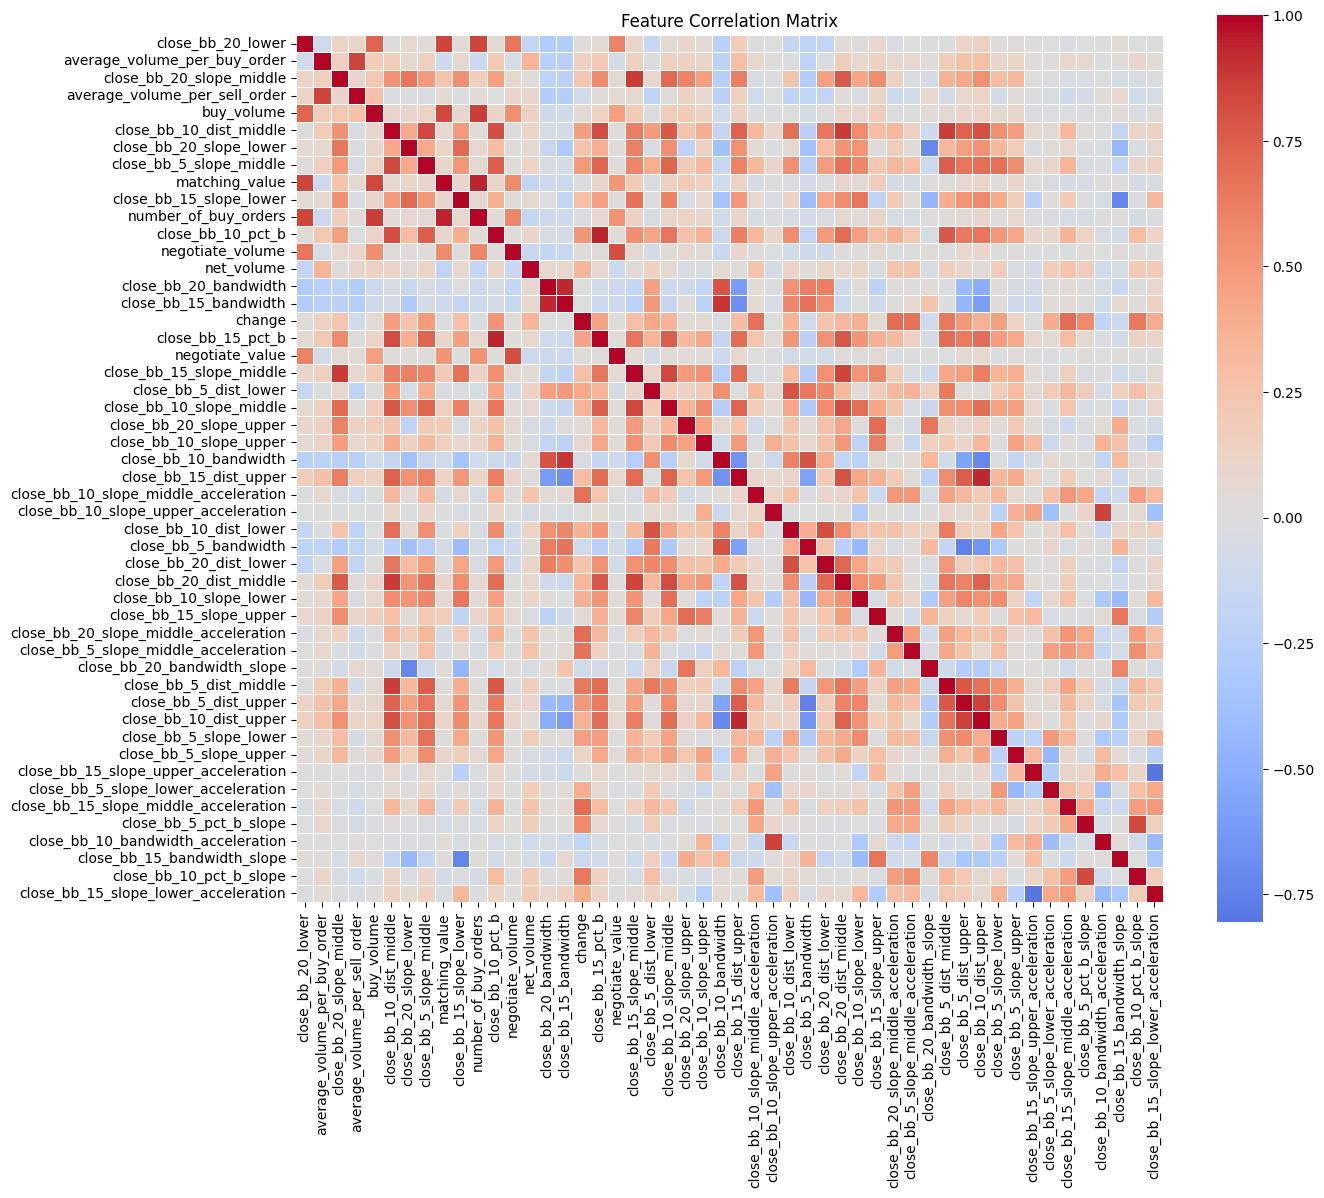

In [ ]:
corr_matrix = input_df[selected_features[:TOP_N]].corr()

print("Correlation Matrix:")
display(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
FINAL_FEATURE_COLUMNS = selected_features[:TOP_N]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Final feature count:", len(FINAL_FEATURE_COLUMNS))

X_fs = input_df[FINAL_FEATURE_COLUMNS].dropna().reset_index(drop=True)
X_fs

Original feature count: 110
Final feature count: 50


,close_bb_20_lower,average_volume_per_buy_order,close_bb_20_slope_middle,average_volume_per_sell_order,buy_volume,close_bb_10_dist_middle,close_bb_20_slope_lower,close_bb_5_slope_middle,matching_value,close_bb_15_slope_lower,...,close_bb_5_slope_lower,close_bb_5_slope_upper,close_bb_15_slope_upper_acceleration,close_bb_5_slope_lower_acceleration,close_bb_15_slope_middle_acceleration,close_bb_5_pct_b_slope,close_bb_10_bandwidth_acceleration,close_bb_15_bandwidth_slope,close_bb_10_pct_b_slope,close_bb_15_slope_lower_acceleration
0,456.437563,2104.0,-5.79800,1972.0,3.828609e+07,0.044897,2.644063,5.096,1.091250e+11,9.995384,...,1.959411,8.232589,6.330358,-2.319411,2.494667,0.070382,0.036161,-0.053693,0.067338,-1.341025
1,458.721207,2242.0,-4.50750,2093.0,4.653044e+07,0.046433,2.283644,5.514,1.230387e+12,5.877106,...,2.899765,8.128235,8.608944,0.940354,2.245333,-0.042610,-0.016568,-0.031235,0.006789,-4.118278
2,463.461669,1995.0,-4.59250,1600.0,2.034775e+07,0.043658,4.740461,5.388,5.319666e+11,3.419691,...,5.090183,5.685817,4.897415,2.190418,1.220000,-0.060552,0.001763,-0.017920,-0.041137,-2.457415
3,471.050258,2547.0,-5.09350,1757.0,1.112623e+07,0.024547,7.588590,3.300,4.332767e+11,2.709494,...,7.799367,-1.199367,1.018197,2.709184,0.154000,-0.260819,-0.011622,-0.014773,-0.159846,-0.710197
4,481.669041,2477.0,-5.23950,1801.0,1.000545e+07,0.006957,10.618783,1.202,4.037687e+11,0.398773,...,5.077035,-2.673035,3.966721,-2.722332,0.828000,-0.410525,-0.005432,-0.003097,-0.166290,-2.310721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4659,1734.009671,2738.0,-2.75200,3254.0,1.061450e+09,0.019429,0.682483,13.720,1.890820e+13,6.230056,...,5.834477,21.605523,3.107776,14.980694,1.462667,-0.083179,-0.001396,-0.010252,0.110443,-0.182443
4660,1737.479351,2689.1,-3.08425,3185.3,1.118916e+09,0.023847,3.469681,16.017,2.002960e+13,1.083225,...,18.152043,13.881957,10.198164,12.317566,2.525667,-0.034611,0.008565,-0.001836,0.031778,-5.146831
4661,1741.560768,2672.8,-2.76350,3162.4,1.138071e+09,0.024424,4.081416,16.896,2.040340e+13,-0.800609,...,43.329437,-9.537437,4.127167,25.177394,1.121667,0.012761,-0.000964,0.001465,-0.024257,-1.883834
4662,1745.245894,2656.5,-2.16625,3139.5,1.157227e+09,0.023542,3.685126,9.053,2.077720e+13,-1.126653,...,18.663899,-0.557899,4.485377,-24.665538,2.079667,-0.002195,0.000525,0.004059,-0.041852,-0.326044


## Save Data

### Create Result Folder

In [ ]:
FEATURE_SELECTION_RESULT_DIR

'../../src/feature_selection/feature_selection_result'

In [ ]:
os.makedirs(FEATURE_SELECTION_RESULT_DIR, exist_ok=True)

In [ ]:
FUNCTION_NAME

'add_bbands'

In [ ]:
importance_df

,feature,importance,importance_pct
89,close_bb_20_lower,1.836833e+02,3.382820e+01
13,average_volume_per_buy_order,8.980773e+01,1.653952e+01
41,close_bb_10_upper,1.656247e+01,3.050242e+00
87,close_bb_20_upper,1.574221e+01,2.899177e+00
95,close_bb_20_slope_middle,1.445013e+01,2.661221e+00
...,...,...,...
39,close_bb_5_inside_bands,2.646978e-23,4.874831e-24
40,close_bb_5_position,2.646978e-23,4.874831e-24
61,close_bb_10_below_lower,2.646978e-23,4.874831e-24
109,close_bb_20_position,2.646978e-23,4.874831e-24


In [ ]:
importance_df.to_csv(
    os.path.join(FEATURE_SELECTION_RESULT_DIR, f"{FUNCTION_NAME}_importance.csv"),
    header=True,
    index=False,
)